<a href="https://colab.research.google.com/github/miffylim2308/ADALL_github/blob/main/ADALL_My_Template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#<font color = 'red'>**dated 30.07.2026 2pm**


- Ctrl + / to remark/unremark
- Ctrl + ] to ident right
- Ctrl + [ to indet left

#**Session 1: From business problem to clean dataset**

#**Chapter 1. Setup and load libraries**

In [6]:
# Core Libraries
import os
import shutil
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

# Modelling libraries and preprocessing
from sklearn.model_selection import train_test_split, ShuffleSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

RANDOM_STATE = 42

#rmse = np.sqrt(mean_squared_error(y_true, y_pred))#mse = mean_squared_error(y_true, y_pred)


print('Setup complete')
# Make wide tables easier to read in Colab
pd.set_option('display.max_columns', 100)

Setup complete


#**Chapter 2. Load the dataset**

In [7]:
#Load dataset from github
github_raw_url = 'https://raw.githubusercontent.com/rq-goh/ADALL_github/refs/heads/main/laptop_prices_2024_sgd_TL.csv'

df = pd.read_csv(github_raw_url)

print('Dataset loaded successfully.')
print('Shape:', df.shape)
display(df.head())

#Load dataset from kaggle
#path = kagglehub.dataset_download("devansodariya/student-performance-data")
#print("Downloaded to:", path)
#print(os.listdir(path))
#df = pd.read_csv(os.path.join(path, "student_data.csv"))

# This cell loads the laptop price dataset directly from GitHub.
# The GitHub raw URL points to the actual CSV file, not the normal GitHub preview page.
# pd.read_csv() reads the CSV file and stores it as a pandas DataFrame called df.
# df.shape shows the number of rows and columns in the dataset.
# df.head() displays the first 5 rows so we can quickly check that the data loaded correctly.

Dataset loaded successfully.
Shape: (1000, 15)


,Unnamed: 0,Brand,Model,CPU,GPU,RAM_GB,Storage_Type,Storage_GB,Touchscreen,Weight_kg,Screen_Size_inch,Discount_percent,Price_SGD,Brand_Discount,Member_Discount
0,0,Acer,Aspire 5,Intel i9-14900HK,NVIDIA RTX 4070,64,SSD,256,False,1.56,16.0,5.28,3207.60,80,160.38
1,1,Acer,Nitro 5,AMD Ryzen 9 8900HX,AMD Radeon 780M,32,SSD,1024,True,1.45,14.0,6.01,2568.40,80,179.79
2,2,Acer,Nitro 5,AMD Ryzen 5 8600H,NVIDIA RTX 4050,32,SSD,2048,False,1.34,14.0,6.56,2050.80,80,143.56
3,3,Acer,TravelMate P6,Intel Core Ultra 7 15500H,NVIDIA RTX 4060,16,SSD,4096,True,1.18,13.3,4.62,2477.59,80,173.43
4,4,Acer,Predator Helios 300,Intel i7-14800H,NVIDIA RTX 4070,8,SSD,1024,True,1.31,14.0,4.81,2626.40,80,183.85


#**Chapter 2a. Set up OpenAI**

In [8]:
# Default method: copy the prompt into the chatbot manually.
RUN_API_CELLS = True
OPENAI_MODEL = 'gpt-5.4-nano'
client = None

# Only use this section if your tutor has asked you to call the API from Colab.
# You must first save OPENAI_API_KEY in Colab Secrets.

if RUN_API_CELLS == True:
    from google.colab import userdata
    from openai import OpenAI

    api_key = userdata.get('OPENAI_API_KEY')
    client = OpenAI(api_key=api_key)
    print('OpenAI client is ready.')
else:
    print('Manual chatbot mode. Copy the prompts when they appear.')

# This cell prepares the notebook to use the OpenAI API, if needed.
# RUN_API_CELLS controls whether the notebook uses the API or manual chatbot mode.
# If RUN_API_CELLS is True, the notebook will try to connect to OpenAI using an API key.
# If RUN_API_CELLS is False, students can copy the prompt and paste it into ChatGPT manually.
# OPENAI_MODEL stores the model name that will be used later when sending prompts.
# client starts as None first, then becomes an OpenAI client after the API key is loaded.
# userdata.get('OPENAI_API_KEY') reads the API key saved in Colab Secrets.
# OpenAI(api_key=api_key) creates the connection object used to call the API.


OpenAI client is ready.


In [4]:
# TESTING THE PROMPT
prompt_test = f"""
I am testing the prompt generator.
"""
print('=== Prompt to send ===')
print(prompt_test[:2000])

if client is not None:
    response_test = client.responses.create(
        model=OPENAI_MODEL,
        input=prompt_test
    )
    print('\n=== LLM response ===')
    print(response_test.output_text)
else:
    print('\nNo API response because client is not connected. Copy the prompt above into your chatbot.')

=== Prompt to send ===

I am testing the prompt generator.


=== LLM response ===
Got it—I’m here and ready to test the prompt generator.

What would you like to generate prompts for (e.g., a specific task, role, topic, format)? If you share:
1) the topic/domain  
2) the audience (or role)  
3) desired output style (bullet points, JSON, multiple variations, etc.)  
4) number of prompts  

…I can generate a set for you.


#**Chapter 3. LLM-assisted problem framing**

In [9]:
# PROMPT
prompt1 = f"""
You are an expert data scientist with experience in tree-based regression models.
Help me translate this business problem into a modelling objective.

Business problem: A refurbished laptop seller wants to price laptops fairly and consistently.
Dataset context: The dataset contains laptop specifications and price in SGD.

Please answer:
What should the modelling objective be?
What is the most meaningful target column?
Which metric would be easiest to explain to business users?
Who are the main stakeholders?
What are three risks or pitfalls?
"""
print('=== Prompt to send ===')
print(prompt1[:2000])

if client is not None:
    response = client.responses.create(
        model=OPENAI_MODEL,
        input=prompt1
    )
    print('\n=== LLM response ===')
    print(response.output_text)
else:
    print('\nNo API response because client is not connected. Copy the prompt above into your chatbot.')


=== Prompt to send ===

You are an expert data scientist with experience in tree-based regression models.
Help me translate this business problem into a modelling objective.

Business problem: A refurbished laptop seller wants to price laptops fairly and consistently.
Dataset context: The dataset contains laptop specifications and price in SGD.

Please answer:
What should the modelling objective be?
What is the most meaningful target column?
Which metric would be easiest to explain to business users?
Who are the main stakeholders?
What are three risks or pitfalls?


=== LLM response ===
## 1) Modelling objective
Build a **supervised regression model** that predicts a laptop’s **fair market resale price (in SGD)** from its specifications (e.g., CPU/GPU, RAM, storage, screen size/resolution, condition, brand, age, etc.), so the seller can:
- **Quote prices consistently** for new listings,
- **Reduce pricing subjectivity**, and
- **Adjust quickly** as inventory mix and market patterns cha

#<font color='red'>**Chapter 4. Quick dataset inspection before using an LLM**

In [13]:
print('Shape:', df.shape)

display(df.head())

print('\nInfo:')
display(df.info())

print('\nColumns:', df.columns.tolist())

print("\nDescribe:")
display(df.describe(include='all').transpose())

missing_values = df.isnull().sum()
print("Missing values:\n", missing_values)

duplicate_count = df.duplicated().sum()
print("\nDuplicate count:", duplicate_count)

Shape: (1000, 15)


,Unnamed: 0,Brand,Model,CPU,GPU,RAM_GB,Storage_Type,Storage_GB,Touchscreen,Weight_kg,Screen_Size_inch,Discount_percent,Price_SGD,Brand_Discount,Member_Discount
0,0,Acer,Aspire 5,Intel i9-14900HK,NVIDIA RTX 4070,64,SSD,256,False,1.56,16.0,5.28,3207.60,80,160.38
1,1,Acer,Nitro 5,AMD Ryzen 9 8900HX,AMD Radeon 780M,32,SSD,1024,True,1.45,14.0,6.01,2568.40,80,179.79
2,2,Acer,Nitro 5,AMD Ryzen 5 8600H,NVIDIA RTX 4050,32,SSD,2048,False,1.34,14.0,6.56,2050.80,80,143.56
3,3,Acer,TravelMate P6,Intel Core Ultra 7 15500H,NVIDIA RTX 4060,16,SSD,4096,True,1.18,13.3,4.62,2477.59,80,173.43
4,4,Acer,Predator Helios 300,Intel i7-14800H,NVIDIA RTX 4070,8,SSD,1024,True,1.31,14.0,4.81,2626.40,80,183.85



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1000 non-null   int64  
 1   Brand             1000 non-null   object 
 2   Model             1000 non-null   object 
 3   CPU               1000 non-null   object 
 4   GPU               1000 non-null   object 
 5   RAM_GB            1000 non-null   int64  
 6   Storage_Type      1000 non-null   object 
 7   Storage_GB        1000 non-null   int64  
 8   Touchscreen       1000 non-null   bool   
 9   Weight_kg         1000 non-null   float64
 10  Screen_Size_inch  1000 non-null   float64
 11  Discount_percent  1000 non-null   float64
 12  Price_SGD         1000 non-null   float64
 13  Brand_Discount    1000 non-null   int64  
 14  Member_Discount   1000 non-null   float64
dtypes: bool(1), float64(5), int64(4), object(5)
memory usage: 110.5+ KB


None


Columns: ['Unnamed: 0', 'Brand', 'Model', 'CPU', 'GPU', 'RAM_GB', 'Storage_Type', 'Storage_GB', 'Touchscreen', 'Weight_kg', 'Screen_Size_inch', 'Discount_percent', 'Price_SGD', 'Brand_Discount', 'Member_Discount']

Describe:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,1000.0,NaN,NaN,NaN,499.5,288.819436,0.0,249.75,499.5,749.25,999.0
Brand,1000,6,Asus,177,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Model,1000,30,Predator Helios 300,48,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CPU,1000,10,Intel i5-14600H,114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GPU,1000,9,NVIDIA RTX 4070,268,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RAM_GB,1000.0,NaN,NaN,NaN,53.128,44.413288,8.0,16.0,32.0,64.0,128.0
Storage_Type,1000,1,SSD,1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Storage_GB,1000.0,NaN,NaN,NaN,1505.024,1380.203919,256.0,512.0,1024.0,2048.0,4096.0
Touchscreen,1000,2,False,505,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Weight_kg,1000.0,NaN,NaN,NaN,2.03656,0.746477,1.0,1.34,1.97,2.68,3.5


Missing values:
 Unnamed: 0          0
Brand               0
Model               0
CPU                 0
GPU                 0
RAM_GB              0
Storage_Type        0
Storage_GB          0
Touchscreen         0
Weight_kg           0
Screen_Size_inch    0
Discount_percent    0
Price_SGD           0
Brand_Discount      0
Member_Discount     0
dtype: int64

Duplicate count: 0


#**Chapter 5. First LLM touchpoint: send only a small preview**

In [11]:
data_preview = df.head(10).to_string()
print(data_preview[:1500])

   Unnamed: 0 Brand                Model                        CPU              GPU  RAM_GB Storage_Type  Storage_GB  Touchscreen  Weight_kg  Screen_Size_inch  Discount_percent  Price_SGD  Brand_Discount  Member_Discount
0           0  Acer             Aspire 5           Intel i9-14900HK  NVIDIA RTX 4070      64          SSD         256        False       1.56              16.0              5.28    3207.60              80           160.38
1           1  Acer              Nitro 5         AMD Ryzen 9 8900HX  AMD Radeon 780M      32          SSD        1024         True       1.45              14.0              6.01    2568.40              80           179.79
2           2  Acer              Nitro 5          AMD Ryzen 5 8600H  NVIDIA RTX 4050      32          SSD        2048        False       1.34              14.0              6.56    2050.80              80           143.56
3           3  Acer        TravelMate P6  Intel Core Ultra 7 15500H  NVIDIA RTX 4060      16          SSD       

In [14]:
preview_prompt = f"""
Here are the first 10 rows of a laptop pricing dataset:

{data_preview}

Questions:
1. What does each row appear to represent?
2. Which column is likely the target for a price prediction model?
3. What are 3 possible data quality checks we should perform before modelling?

Keep the answer short and practical.
"""
print('=== Prompt to send ===')
print(preview_prompt[:2000])

if client is not None:
    response = client.responses.create(
        model=OPENAI_MODEL,
        input=preview_prompt
    )
    print('\n=== LLM response ===')
    print(response.output_text)
else:
    print('\nNo API response because client is not connected. Copy the prompt above into your chatbot.')

=== Prompt to send ===

Here are the first 10 rows of a laptop pricing dataset:

   Unnamed: 0 Brand                Model                        CPU              GPU  RAM_GB Storage_Type  Storage_GB  Touchscreen  Weight_kg  Screen_Size_inch  Discount_percent  Price_SGD  Brand_Discount  Member_Discount
0           0  Acer             Aspire 5           Intel i9-14900HK  NVIDIA RTX 4070      64          SSD         256        False       1.56              16.0              5.28    3207.60              80           160.38
1           1  Acer              Nitro 5         AMD Ryzen 9 8900HX  AMD Radeon 780M      32          SSD        1024         True       1.45              14.0              6.01    2568.40              80           179.79
2           2  Acer              Nitro 5          AMD Ryzen 5 8600H  NVIDIA RTX 4050      32          SSD        2048        False       1.34              14.0              6.56    2050.80              80           143.56
3           3  Acer        Trav

#<font color='red'>**Chapter 7. Build the payload text**</font>

In [15]:
# Build payload text step by step.
# Payload text is a short profile of the dataset.
# It is safer and smaller than sending the full dataset to the LLM.

payload_text = ''

# 0. Business objective
payload_text += '=== BUSINESS OBJECTIVE ===\n'
payload_text += 'Dataset context: The dataset contains refurbished laptop specifications and price in SGD.\n'
payload_text += 'Business Goal: Predict laptop prices based on laptop specifications.\n'
payload_text += 'Intended Users: Owner of the shop which sells refurbished laptops so needs to set a reasonable and competitive price.\n'
payload_text += 'Questions:\n'
payload_text += '- Which features influence laptop price?\n'
payload_text += '- What data quality issues exist?\n'
payload_text += '- What preprocessing is required?\n\n'

# 1. Shape
payload_text += '=== SHAPE ===\n'
payload_text += 'Rows: ' + str(df.shape[0]) + '\n'
payload_text += 'Columns: ' + str(df.shape[1]) + '\n\n'

# 2. Sample records
payload_text += '=== SAMPLE RECORDS ===\n'
payload_text += df.head(5).to_string(index=False)
payload_text += '\n\n'

# 3. Column names and data types
payload_text += '=== COLUMNS AND DATA TYPES ===\n'
payload_text += df.dtypes.to_string()
payload_text += '\n\n'

# 4. Numeric summary
payload_text += '=== NUMERIC SUMMARY ===\n'
numeric_summary = df.describe(include='number').round(2)
payload_text += numeric_summary.to_string()
payload_text += '\n\n'

# 5. Null summary
payload_text += "=== NULL SUMMARY ===\n"
null_summary = (
    df.isna().sum().to_frame("null_count")
    .assign(null_pct=lambda x: x["null_count"]/len(df))
)
payload_text += null_summary.to_string()
payload_text += '\n\n'

# 6. Missing values
payload_text += '=== MISSING VALUES ===\n'
missing_table = pd.DataFrame()
missing_table['missing_count'] = df.isna().sum()
missing_table['missing_pct'] = (df.isna().sum() / len(df) * 100).round(2)
payload_text += missing_table.to_string()
payload_text += '\n\n'

# 7. Unique values per column
payload_text += '=== UNIQUE VALUES PER COLUMN ===\n'
unique_table = pd.DataFrame()
unique_table['unique_count'] = df.nunique(dropna=False)
payload_text += unique_table.to_string()
payload_text += '\n\n'

# 8 Correlation between numeric columns
payload_text += '=== CORRELATION BETWEEN NUMERIC COLUMNS ===\n'
correlation_table = df.corr(numeric_only=True).round(2)
payload_text += correlation_table.to_string()
payload_text += '\n\n'

# 9. Top 10 values for categorical columns
payload_text += '=== TOP 10 VALUES FOR CATEGORICAL COLUMNS ===\n'

categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()

if len(categorical_columns) == 0:
    payload_text += 'No categorical columns found.\n'
else:
    for col in categorical_columns:
        payload_text += '\nColumn: ' + col + '\n'
        payload_text += df[col].value_counts(dropna=False).head(10).to_string()
        payload_text += '\n'

payload_text += '\n'

# 10. Skewness of numeric columns
payload_text += '=== SKEWNESS OF NUMERIC COLUMNS ===\n'
skew_table = df.select_dtypes(include='number').skew().round(2)
payload_text += skew_table.to_string()
payload_text += '\n\n'

# 11. Outlier summary
payload_text += '=== OUTLIER SUMMARY (IQR METHOD) ===\n'

numeric_columns = df.select_dtypes(include='number').columns

for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = ((df[column] < lower_bound) | (df[column] > upper_bound)).sum()
    outlier_pct = round(outlier_count / len(df) * 100, 2)

    payload_text += f'{column}: {outlier_count} ({outlier_pct}%)\n'

payload_text += '\n'

# 12. Leakage scan: columns with all unique values
payload_text += "=== POSSIBLE LEAKAGE COLUMNS (UNIQUE FOR EACH ROW) ===\n"
leak_cols = df.columns[df.nunique() == len(df)]
payload_text +=str(list(leak_cols))
payload_text +="\n\n"

# 13. Simple warning checks
payload_text += '=== SIMPLE WARNING CHECKS ===\n'

id_like_columns = []
constant_columns = []

for col in df.columns:
    unique_count = df[col].nunique(dropna=False)

    if unique_count == len(df):
        id_like_columns.append(col)

    if unique_count <= 1:
        constant_columns.append(col)
payload_text += 'Possible ID-like columns: ' + str(id_like_columns) + '\n'
payload_text += 'Constant columns: ' + str(constant_columns) + '\n'
duplicate_count = df.duplicated().sum()
duplicate_pct = round(duplicate_count / len(df) * 100, 2)
payload_text += (
    f'Duplicate rows: {duplicate_count} ({duplicate_pct}%)\n'
)

print(payload_text)

# This cell builds a short dataset profile called payload_text.
# Instead of sending the full dataset to the LLM, we send summary information only.
# The payload includes shape, column types, numeric summary, missing values, unique counts, correlations, and common category values.
# It also adds simple warning checks for possible ID-like columns, constant columns, and duplicate rows.
# This helps the LLM comment on data readiness without needing every row of the dataset.

=== BUSINESS OBJECTIVE ===
Dataset context: The dataset contains refurbished laptop specifications and price in SGD.
Business Goal: Predict laptop prices based on laptop specifications.
Intended Users: Owner of the shop which sells refurbished laptops so needs to set a reasonable and competitive price.
Questions:
- Which features influence laptop price?
- What data quality issues exist?
- What preprocessing is required?

=== SHAPE ===
Rows: 1000
Columns: 15

=== SAMPLE RECORDS ===
 Unnamed: 0 Brand               Model                       CPU             GPU  RAM_GB Storage_Type  Storage_GB  Touchscreen  Weight_kg  Screen_Size_inch  Discount_percent  Price_SGD  Brand_Discount  Member_Discount
          0  Acer            Aspire 5          Intel i9-14900HK NVIDIA RTX 4070      64          SSD         256        False       1.56              16.0              5.28    3207.60              80           160.38
          1  Acer             Nitro 5        AMD Ryzen 9 8900HX AMD Radeon 780M 

# <font color='red'>**Chapter 8. Ask the LLM to review data quality using payload text**


In [16]:
prompt_quality = f"""
You are an expert data scientist with extensive knowledge of tree-based models.
Always justify recommendations using reasoning trace based ONLY on the dataset profile.
============================
DATASET PROFILE
============================
{payload_text}

============================
TASK
============================
Assess the dataset's quality and modelling readiness.

1. Identify all confirmed data quality or modelling-readiness issues.

For each issue, provide:
- Issue
- Column(s) affected
- Evidence from the dataset profile
- Why it may affect analysis or modelling
- Recommended action
- Priority (High / Medium / Low)

2. Identify any potential issues that require further investigation but cannot be confirmed from the dataset profile alone.

3. Highlight the strengths of the dataset (for example, no missing values, no duplicates, appropriate data types, etc.).

4. State whether the dataset is ready for machine learning modelling using ONE of the following ratings:
- Ready
- Ready with Minor Cleaning
- Ready with Moderate Cleaning
- Not Ready
Provide a brief justification.

5. Recommend the Top 3 next steps before modelling.

6. Provide a python script to handle the identified issues.
- Define one helper function for each issue.
- Then define a wrapper function that calls these helper with true false option as user choice
- Provide a single line of code to run the overall wrapper function.
- Do not encode categorical columns or model first.

========================
IMPORTANT INSTRUCTIONS
========================

- Use only the information contained in the dataset profile.
- Do NOT assume information that is not provided.
- If evidence is unavailable, state "Not available" instead of guessing.
- Reference the relevant dataset profile section whenever possible (e.g., Missing Values, Numeric Summary, Correlation Matrix, Warning Checks).
- Do NOT recommend dropping a column solely because it appears in a warning.
- Treat ID-like, high-cardinality, constant, near-constant and outlier warnings as items requiring investigation, not automatic removal.
- Do NOT treat correlation as proof of causation.
- Do NOT recommend removing outliers unless there is evidence they are invalid or unsuitable for the business objective.
- If skewness, outlier summary, feature importance, or other analyses are not included in the dataset profile, state that they were not available instead of inferring results.
- Distinguish clearly between confirmed issues and potential issues.
- Keep recommendations practical, concise, and suitable for a data analytics student.

========================
OUTPUT FORMAT
========================

Overall Modelling Readiness
---------------------------
Readiness Rating:
Brief Justification:

Confirmed Issues
----------------
For each issue, use the following format:

Issue:
Column(s):
Evidence:
Impact:
Recommended Action:
Priority:

Potential Issues Requiring Investigation
-----------------------------------------
For each potential issue, use:

Issue:
Reason Further Investigation is Needed:

Dataset Strengths
-----------------
- ...
- ...
- ...

Checks with No Issues
---------------------
- ...
- ...
- ...

Top 3 Recommended Next Steps
----------------------------
1.
2.
3.

Overall Summary
---------------
Provide a concise summary (3–5 sentences) describing the dataset's overall quality and readiness for machine learning modelling.
"""

if client is not None:
    response_quality= client.responses.create(
        model=OPENAI_MODEL,
        input=prompt_quality
    )
    print('\n=== LLM response ===')
    print(response_quality.output_text)
else:
    print('\nNo API response because client is not connected. Copy the prompt above into your chatbot.')

# This cell asks the LLM to review the dataset profile for modelling-readiness issues.
# The LLM does not receive the full dataset, only the summary stored in payload_text.
# The prompt asks for possible issues and practical remedies.
# The instructions help prevent the LLM from making unsupported assumptions or dropping columns too quickly.
# If the API client is connected, the prompt is sent automatically.
# Otherwise, students can copy the prompt and use the chatbot manually.


=== LLM response ===
Overall Modelling Readiness
---------------------------
Readiness Rating: **Ready with Minor Cleaning**

Brief Justification:  
The dataset has **no missing values**, **no duplicate rows**, and all columns have usable data types for tree-based models (numeric + categorical + boolean). However, there are **confirmed modeling-readiness issues**: an **ID-like column** (`Unnamed: 0`) that can leak row identity, and **target/price-magnitude checks** where some discount-related columns may be engineered/duplicative from the business fields. There is also **limited evidence on invalid values** (e.g., whether discount fields or prices are always within sensible ranges), so minor cleaning and basic validation are appropriate before modelling.

Confirmed Issues
----------------
### 1) Issue: ID-like / row identifier feature leakage
- **Issue:** Presence of an ID-like column that is effectively unique per row and can cause spurious splits or memorization.
- **Column(s):** `U

#<font color='red'>**COPY the Output from above and output Python codes to clean your dataset**

In [17]:
prompt_clean = f"""
You are an expert data scientist with experience in tree-based regression models.
Generate simple and executable python code to fix each of the following issues, only for data cleaning purposes, do not model yet.
Target is ccolumn Price_SGD
Input is df, and output should be cleaned_df.
Issues:
{response_quality.output_text}

Additionally, generate code for:
- remove Possible ID-like columns, Constant columns, Discount-related columns
Lastly, show the columns of df and cleaned_df, to compare the differences, i.e. which columns are added or removed

"""
## below are optionals... ##
#Additionally, generate code for:
#- safe column checks
#- Extreme sparsity / large cardinality in categoricals
#- Robust outlier clipping (only for plausibly bounded numeric features)
#- Apply clipping to numeric predictors only (exclude target if present)
#- ensure no accidental all-null columns
## ---------------------------------##

if client is not None:
    response_clean = client.responses.create(
        model=OPENAI_MODEL,
        input=prompt_clean
    )
    print('\nLLM response:')
    print(response_clean.output_text)
else:
    print('\nNo API response because client is not connected. Copy the prompt above into your chatbot.')


LLM response:
```python
import pandas as pd
import numpy as np

def clean_laptop_price_data(
    df: pd.DataFrame,
    target_col: str = "Price_SGD",
    id_like_col: str = "Unnamed: 0",
    constant_drop: bool = True,
    drop_discount_cols: bool = False,   # set True to drop ALL discount-related cols
    verbose: bool = True
) -> pd.DataFrame:
    """
    Data cleaning only (no modeling).
    - Drops confirmed ID-like column (default: Unnamed: 0)
    - Drops constant columns (default: True)
    - Optionally drops discount-related columns (data-only choice via drop_discount_cols)
    """
    if target_col not in df.columns:
        raise ValueError(f"Target column '{target_col}' not found in df.")

    cleaned_df = df.copy()

    # -----------------------
    # 1) Remove ID-like column
    # -----------------------
    if id_like_col in cleaned_df.columns:
        unique_ratio = cleaned_df[id_like_col].nunique(dropna=False) / len(cleaned_df)
        if verbose:
            print(f"[I

In [18]:
import pandas as pd

# ----------------------------
# Data cleaning only (no modeling)
# Target: Price_SGD
# Input: df
# Output: cleaned_df
# ----------------------------

def clean_for_modelling(
    df: pd.DataFrame,
    target_col: str = "Price_SGD",
    drop_id_like: bool = True,
    drop_constant: bool = True,
    drop_discount_related: bool = False,  # set True only if you want the discount-feature columns removed
    verbose: bool = True,
) -> pd.DataFrame:
    cleaned_df = df.copy()

    original_cols = set(cleaned_df.columns)

    # ---- 1) Remove ID-like columns (confirmed: Unnamed: 0) ----
    if drop_id_like:
        # Safe heuristics: explicitly drop known id-like columns + any column with "id-like" naming
        id_like_candidates = []
        if "Unnamed: 0" in cleaned_df.columns:
            id_like_candidates.append("Unnamed: 0")
        id_like_candidates += [
            c for c in cleaned_df.columns
            if c.lower() in {"id", "identifier", "index"} or "unnamed" in c.lower()
        ]
        id_like_candidates = sorted(set(id_like_candidates))

        # Also drop any column that is perfectly unique per row (typical row-id proxy)
        # Only if it is not the target.
        n = len(cleaned_df)
        unique_per_row = [
            c for c in cleaned_df.columns
            if c != target_col and cleaned_df[c].nunique(dropna=False) == n
        ]

        id_like_to_drop = sorted(set(id_like_candidates).union(unique_per_row))
        if id_like_to_drop:
            cleaned_df = cleaned_df.drop(columns=id_like_to_drop)
    # ---- 2) Drop constant columns (confirmed: Storage_Type) ----
    if drop_constant:
        constant_cols = [
            c for c in cleaned_df.columns
            if cleaned_df[c].nunique(dropna=False) <= 1
        ]
        if constant_cols:
            cleaned_df = cleaned_df.drop(columns=constant_cols)

    # ---- 3) Optional: remove discount-related columns ----
    # (Not required by your confirmed issues; included because you asked for it.)
    if drop_discount_related:
        discount_cols = [
            "Discount_percent",
            "Brand_Discount",
            "Member_Discount",
        ]
        present = [c for c in discount_cols if c in cleaned_df.columns]
        if present:
            cleaned_df = cleaned_df.drop(columns=present)

    # Ensure target still exists
    if target_col not in cleaned_df.columns:
        raise ValueError(f"Cleaning removed the target column '{target_col}'. Check the cleaning rules.")

    if verbose:
        removed_cols = sorted(original_cols - set(cleaned_df.columns))
        added_cols = sorted(set(cleaned_df.columns) - original_cols)
        print("=== Column comparison ===")
        print(f"Original columns: {df.shape[1]}")
        print(f"Cleaned columns:  {cleaned_df.shape[1]}")
        print(f"Removed columns ({len(removed_cols)}): {removed_cols}")
        print(f"Added columns ({len(added_cols)}): {added_cols}")

    return cleaned_df


# ----------------------------
# Run cleaning
# ----------------------------
cleaned_df = clean_for_modelling(
    df,
    target_col="Price_SGD",
    drop_id_like=True,        # confirmed high priority
    drop_constant=True,      # confirmed medium priority
    drop_discount_related=True,  # keep discounts by default (recommended "caution, not automatic removal")
    verbose=True
)

# If you want the *discount-removal variant* too (optional), uncomment:
# cleaned_df_no_discounts = clean_for_modelling(
#     df, drop_id_like=True, drop_constant=True, drop_discount_related=True, verbose=True
# )

# ----------------------------
# Show columns to compare (explicitly)
# ----------------------------
print("\nColumns in df:")
print(list(df.columns))

print("\nColumns in cleaned_df:")
print(list(cleaned_df.columns))


=== Column comparison ===
Original columns: 15
Cleaned columns:  10
Removed columns (5): ['Brand_Discount', 'Discount_percent', 'Member_Discount', 'Storage_Type', 'Unnamed: 0']
Added columns (0): []

Columns in df:
['Unnamed: 0', 'Brand', 'Model', 'CPU', 'GPU', 'RAM_GB', 'Storage_Type', 'Storage_GB', 'Touchscreen', 'Weight_kg', 'Screen_Size_inch', 'Discount_percent', 'Price_SGD', 'Brand_Discount', 'Member_Discount']

Columns in cleaned_df:
['Brand', 'Model', 'CPU', 'GPU', 'RAM_GB', 'Storage_GB', 'Touchscreen', 'Weight_kg', 'Screen_Size_inch', 'Price_SGD']


# **Compare df and cleaned_df after cleaning**

In [19]:
# What to check after cleaning:
# 1. Did the number of rows stay the same?
# 2. Did the discount columns disappear?
# 3. Are there missing values that still need attention?
# 4. Does Price_SGD still exist as the target column?

print('Original rows:', df.shape[0])
print('Cleaned rows:', cleaned_df.shape[0])

print('\nMissing values after cleaning:')
missing_after_cleaning = cleaned_df.isna().sum()
display(missing_after_cleaning.sort_values(ascending=False).head(10))

print('\nColumns after cleaning:')
print(cleaned_df.columns.tolist())

Original rows: 1000
Cleaned rows: 1000

Missing values after cleaning:


,0
Brand,0
Model,0
CPU,0
GPU,0
RAM_GB,0
Storage_GB,0
Touchscreen,0
Weight_kg,0
Screen_Size_inch,0
Price_SGD,0



Columns after cleaning:
['Brand', 'Model', 'CPU', 'GPU', 'RAM_GB', 'Storage_GB', 'Touchscreen', 'Weight_kg', 'Screen_Size_inch', 'Price_SGD']


#<font color='red'>**Save your cleaned_df**

In [ ]:
#Saved to GitHub ###
## Download to Google Drive then import to Github manually##

In [ ]:
#Saved to Google colab /content. Files in /content are temporary and disappear when the Colab runtime ends
cleaned_df.to_csv('cleaned_laptop_prices.csv', index=False)

print('Saved cleaned dataset as cleaned_laptop_prices.csv')
print('You can use this file in Session 2.')

import os
print(os.getcwd())
print(os.listdir())

Saved cleaned dataset as cleaned_laptop_prices.csv
You can use this file in Session 2.
/content
['.config', 'cleaned_laptop_prices.csv', 'sample_data']


In [ ]:
# Saved the file in Google Drive > MyDrive

from google.colab import drive
drive.mount('/content/drive')

cleaned_df.to_csv(
    "/content/drive/MyDrive/cleaned_laptop_prices.csv",
    index=False
)

Mounted at /content/drive


In [ ]:
#Saved the file in my PC "Downloads" folder. Then Manually upload to GitHub##

from google.colab import files
files.download("cleaned_laptop_prices.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#**Section 2: From cleaned dataset to baseline model**

#**Chapter 12. Load cleaned_df**

In [20]:
# You may run the following code, if you have the cleaned_laptop_prices.csv file. If not, just rerun earlier cells to re-create it.
#cleaned_df = pd.read_csv('cleaned_laptop_prices.csv')

# Or read the cleaned_laptop_prices.csv  file from Google Drive
# cleaned_df = pd.read_csv("/content/drive/MyDrive/cleaned_laptop_prices.csv")

# read from github
github_raw_url = 'https://raw.githubusercontent.com/zawhtetwai/ADALL_GitHub/refs/heads/main/cleaned_laptop_prices.csv'
cleaned_df = pd.read_csv(github_raw_url)

print('Loaded cleaned_laptop_prices.csv.')
print('Cleaned shape:', cleaned_df.shape)
display(cleaned_df.head())

Loaded cleaned_laptop_prices.csv.
Cleaned shape: (1000, 10)


,Brand,Model,CPU,GPU,RAM_GB,Storage_GB,Touchscreen,Weight_kg,Screen_Size_inch,Price_SGD
0,Acer,Aspire 5,Intel i9-14900HK,NVIDIA RTX 4070,64,256,False,1.56,16.0,3640.18
1,Acer,Nitro 5,AMD Ryzen 9 8900HX,AMD Radeon 780M,32,1024,True,1.45,14.0,3009.03
2,Acer,Nitro 5,AMD Ryzen 5 8600H,NVIDIA RTX 4050,32,2048,False,1.34,14.0,2434.03
3,Acer,TravelMate P6,Intel Core Ultra 7 15500H,NVIDIA RTX 4060,16,4096,True,1.18,13.3,2863.30
4,Acer,Predator Helios 300,Intel i7-14800H,NVIDIA RTX 4070,8,1024,True,1.31,14.0,3036.30


#<font color = 'red'>**Chapter 14. Split into X and y**
- X - Input features used to predict target. It should not contain target column
- y - actual target

In [21]:
target_col = 'Price_SGD'

if target_col not in cleaned_df.columns:
    raise ValueError(f'Target column {target_col} was not found. Check your cleaned dataset columns.')

X = cleaned_df.drop(columns=[target_col])
y = cleaned_df[target_col]

print('X shape:', X.shape)
print('y shape:', y.shape)
print('Target column:', target_col)
display(X.head())
display(y.head())

# This cell separates the dataset into INPUT features X and OUTPUT target y.
# target_col stores the column we want the model to predict, which is Price_SGD.
# The if-statement checks that Price_SGD still exists after data cleaning.
# X contains all columns except the target column.
# y contains only the target column.
# The shape outputs help us check how many rows and columns are being used for modelling.

X shape: (1000, 9)
y shape: (1000,)
Target column: Price_SGD


,Brand,Model,CPU,GPU,RAM_GB,Storage_GB,Touchscreen,Weight_kg,Screen_Size_inch
0,Acer,Aspire 5,Intel i9-14900HK,NVIDIA RTX 4070,64,256,False,1.56,16.0
1,Acer,Nitro 5,AMD Ryzen 9 8900HX,AMD Radeon 780M,32,1024,True,1.45,14.0
2,Acer,Nitro 5,AMD Ryzen 5 8600H,NVIDIA RTX 4050,32,2048,False,1.34,14.0
3,Acer,TravelMate P6,Intel Core Ultra 7 15500H,NVIDIA RTX 4060,16,4096,True,1.18,13.3
4,Acer,Predator Helios 300,Intel i7-14800H,NVIDIA RTX 4070,8,1024,True,1.31,14.0


,Price_SGD
0,3640.18
1,3009.03
2,2434.03
3,2863.30
4,3036.30


#**Chapter 15. Train-Test split**

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2, #0.2 = 20%
    random_state=42 #stratify=y is not use here because this is regression problem.
)

print('Training rows:', X_train.shape[0])
print('Test rows:', X_test.shape[0])

#value count for y_train and y_test
#print(y_train.value_counts(normalize=True))
#print(y_test.value_counts(normalize=True))

Training rows: 800
Test rows: 200


#**Chapter 16. Identify numeric and categorical columns**
- Numeric column - Scale using StandardScaler
- Categorical	columns - Convert using OneHotEncoder

In [23]:
cat_columns = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
num_columns = X_train.select_dtypes(exclude=['object', 'category']).columns.tolist()

print('Categorical columns:', cat_columns)
print('Numeric columns:', num_columns)
# This cell separates the input columns by data type.
# cat_columns stores text/category columns, such as brand or CPU type.
# num_columns stores numeric columns, such as RAM, storage, or weight.
# This is needed because categorical and numeric columns usually need different preprocessing steps.

Categorical columns: ['Brand', 'Model', 'CPU', 'GPU']
Numeric columns: ['RAM_GB', 'Storage_GB', 'Touchscreen', 'Weight_kg', 'Screen_Size_inch']


#**Chapter 17. Build the preprocessing pipeline**

In [25]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_columns),
        ('num', StandardScaler(), num_columns)
        # ('num', 'passthrough', num_columns) -- use this if numeric columns are passed through without any change. Usually this is better for tree models
    ],
    remainder='drop'
)

preprocessor

# This cell creates the preprocessing steps before modelling.
# OneHotEncoder changes categorical columns into numeric 0/1 columns.
# handle_unknown='ignore' prevents errors if new unseen categories appear later during testing/deployment.
# StandardScaler scales numeric columns so they are on a more similar range.
# ColumnTransformer applies the correct preprocessing to each column group.
# remainder='drop' means columns not listed in cat_columns or num_columns will be removed.

ColumnTransformer(transformers=[('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['Brand', 'Model', 'CPU', 'GPU']),
                                ('num', StandardScaler(),
                                 ['RAM_GB', 'Storage_GB', 'Touchscreen',
                                  'Weight_kg', 'Screen_Size_inch'])])

#**Chapter 18. Train a simple baseline model**

In [26]:
baseline_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(random_state=42, max_depth=12))
])

baseline_model.fit(X_train, y_train)
print('Baseline model trained.')

Baseline model trained.


#**Chapter 19. Evaluate the baseline model**
| Metric | Plain meaning | Better when |
|---|---|---|
| MAE | Average absolute error in dollars | Lower is better |
| RMSE | Error that punishes large mistakes more | Lower is better |
| R² | How much variation is explained | Higher is better |

For business explanation, MAE is often easiest because it is in the same unit as the target: Singapore dollars.

In [28]:
y_pred = baseline_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

baseline_results = pd.DataFrame({
    'Model': ['Baseline Decision Tree'],
    'MAE': [mae],
    'RMSE': [rmse],
    'R2': [r2]
})

display(baseline_results.round(3))

# This cell uses the trained baseline model to predict laptop prices on the test set.
# y_pred stores the predicted prices.
# MAE shows the average absolute prediction error in dollars.
# RMSE also measures prediction error, but gives more penalty to large errors.
# R2 shows how much of the price variation is explained by the model.
# baseline_results stores the metrics in a simple table for comparison later.

,Model,MAE,RMSE,R2
0,Baseline Decision Tree,102.487,146.177,0.961


#<font color='red'>**Chapter 19b. Explain the metrics, preprocessor, model and pipeline**

In [29]:
prompt_evaluate = f"""
You are an expert data scientist with experience in tree-based regression models.
Based on the baseline model results {baseline_results} where target is in SGD
Explain the metrics in simple terms

"""
if client is not None:
    response_evaluate = client.responses.create(
        model=OPENAI_MODEL,
        input=prompt_evaluate
    )
    print('\n=====LLM response=====')
    print(response_evaluate.output_text)
else:
    print('\nNo API response because client is not connected. Copy the prompt above into your chatbot.')


=====LLM response=====
Sure—here’s what each metric means in simple terms for your baseline **Decision Tree** regression model (predicting the target in **SGD**):

### **1) MAE (Mean Absolute Error): 102.49**
- **What it measures:** The *average absolute difference* between your predictions and the actual values.
- **In plain words:** On average, your model’s predictions are off by about **102.49 SGD**, regardless of whether it over- or under-predicts.
- **Lower is better.**

---

### **2) RMSE (Root Mean Squared Error): 146.18**
- **What it measures:** The square root of the *average squared* prediction errors.
- **In plain words:** The model is off by about **146.18 SGD on average**, but it penalizes large mistakes more heavily than MAE.
- **Lower is better**, and RMSE being higher than MAE usually suggests there are some **bigger errors** in the predictions.

---

### **3) R² (R-squared): 0.9611**
- **What it measures:** How much of the variation in the real target values the model

In [30]:
prompt_explain = f"""
You are an expert data scientist with experience in tree-based regression models.
Based on the model {baseline_model} and preprocessor {preprocessor}
Explain in simple terms:
- What the preprocessor does
- What the model does
- Why a pipeline prevents mistakes
"""
if client is not None:
    response_explain = client.responses.create(
        model=OPENAI_MODEL,
        input=prompt_explain
    )
    print('\n=====LLM response=====')
    print(response_explain.output_text)
else:
    print('\nNo API response because client is not connected. Copy the prompt above into your chatbot.')


=====LLM response=====
### 1) What the **preprocessor** does
The preprocessor is a `ColumnTransformer` that treats different column types differently:

- **Categorical columns** (`Brand`, `Model`, `CPU`, `GPU`):
  - Uses **OneHotEncoder(handle_unknown='ignore')**
  - Converts each category into a set of binary features (e.g., “Brand=Apple” becomes 0/1 columns).
  - `handle_unknown='ignore'` means: if the test data has a brand/CPU/GPU category the model didn’t see during training, it won’t crash—it just leaves those unseen categories as all zeros.

- **Numeric columns** (`RAM_GB`, `Storage_GB`, `Touchscreen`, `Weight_kg`, `Screen_Size_inch`):
  - Uses **StandardScaler()**
  - Rescales features to have **mean 0 and standard deviation 1**.
  - This helps the model work more consistently, especially when features are on different scales.

Net effect: it turns your raw table into a clean, numerical feature matrix the model can learn from.

---

### 2) What the **model** does
The model is a

#**Chapter 20. Interpret prediction errors**

In [31]:
error_df = X_test.copy()
error_df['Actual_Price_SGD'] = y_test.values
error_df['Predicted_Price_SGD'] = y_pred.round(2)
error_df['Absolute_Error'] = np.abs(error_df['Actual_Price_SGD'] - error_df['Predicted_Price_SGD']).round(2)

# Show largest errors first
error_df_sorted = error_df.sort_values('Absolute_Error', ascending=False)
display(error_df_sorted.head(10))

# This cell creates an error analysis table for the test set.
# It copies X_test so we can view each laptop together with its prediction result.
# Actual_Price_SGD stores the true price from y_test.
# Predicted_Price_SGD stores the model's predicted price.
# Absolute_Error shows how far the prediction is from the actual price.
# Sorting by Absolute_Error helps us inspect the worst prediction mistakes first.

,Brand,Model,CPU,GPU,RAM_GB,Storage_GB,Touchscreen,Weight_kg,Screen_Size_inch,Actual_Price_SGD,Predicted_Price_SGD,Absolute_Error
292,Asus,TUF Gaming F15,AMD Ryzen 9 8900HX,NVIDIA RTX 4080,64,256,False,1.02,14.0,4114.95,4813.64,698.69
436,Dell,XPS 13,Intel Core Ultra 9 15700H,NVIDIA RTX 4070,64,1024,False,3.47,18.4,3025.14,3535.79,510.65
513,Dell,XPS 13,Intel Core Ultra 7 15500H,NVIDIA RTX 4060,32,1024,True,2.62,18.4,2549.66,3047.69,498.03
942,Microsoft,Surface Book 3,Intel i9-14900HK,NVIDIA RTX 4070,32,4096,True,1.04,14.0,3954.75,3457.73,497.02
210,Asus,ROG Zephyrus G15,Intel i7-14700H,NVIDIA RTX 4070,32,512,False,1.55,16.0,3006.98,3445.69,438.71
529,HP,Spectre x360,Intel Core Ultra 7 15500H,NVIDIA RTX 4060,128,4096,False,2.48,16.0,3622.59,3198.53,424.06
716,Lenovo,ThinkBook 14s,Intel i9-14900HK,NVIDIA RTX 4080,64,4096,True,2.49,15.6,4751.72,4389.78,361.94
974,Microsoft,Surface Book 3,AMD Ryzen 5 8600H,AMD Radeon 680M,16,4096,True,2.70,18.4,2403.31,2083.28,320.03
656,Lenovo,Legion 5,Intel Core Ultra 7 15500H,NVIDIA RTX 4070,8,2048,True,2.18,15.6,2907.03,2596.05,310.98
662,Lenovo,IdeaPad 5,Intel Core Ultra 9 15700H,NVIDIA RTX 4080,128,2048,False,2.97,18.4,4231.48,4533.11,301.63


#**Chapter 21. Cross-validation: avoid trusting one lucky split**

In [32]:
cv = ShuffleSplit(n_splits=10, test_size=0.2, random_state=42)

cv_scores = cross_val_score(
    baseline_model,
    X_train,
    y_train,
    cv=cv,
    scoring='neg_mean_absolute_error'
)

cv_mae = -cv_scores

print('CV MAE scores:', np.round(cv_mae, 2))
print('Mean CV MAE:', round(cv_mae.mean(), 2))
print('Std CV MAE:', round(cv_mae.std(), 2))

# Meaning behind this cell:
# Instead of testing the model only once, cross-validation tests it 10 times using different random train-test splits.
# Each split uses 80% of the data for training and 20% for testing.
# This gives a more reliable view of model performance than one single train-test split.
# scoring='neg_mean_absolute_error' is used because scikit-learn treats higher scores as better.
# Since MAE is an error value, scikit-learn returns it as negative, so we multiply by -1 to get normal MAE values.
# Mean CV MAE shows the average prediction error across the 10 tests.
# Std CV MAE shows how stable or unstable the model performance is across different splits.

CV MAE scores: [120.62 125.23 134.39 134.34 122.71 144.61 134.96 144.76 141.17 136.71]
Mean CV MAE: 133.95
Std CV MAE: 8.2


#<font color='red'>**Chapter 22. Ask LLM to suggest engineered feature**

In [ ]:
columns_text = '\n'.join(X.columns.tolist())

prompt_feature = f"""
I am predicting laptop price using only these columns:
{columns_text}

Suggest 5 engineered features that can be computed only from these columns.
For each feature, explain:
1. why it may help predict price,
2. how to compute it,
3. whether there is any leakage risk.

Keep the answer practical for a beginner data analytics student.
"""

print('===== Prompt preview=====')
print(prompt_feature)

if client is not None:
    response_feature = client.responses.create(
        model=OPENAI_MODEL,
        input=prompt_feature
    )
    print('\n===== LLM response=====')
    print(response_feature.output_text)
else:
    print('\nNo API response because client is not connected. Copy the prompt above into your chatbot.')

===== Prompt preview=====

I am predicting laptop price using only these columns:
Brand
Model
CPU
GPU
RAM_GB
Storage_GB
Touchscreen
Weight_kg
Screen_Size_inch

Suggest 5 engineered features that can be computed only from these columns.
For each feature, explain:
1. why it may help predict price,
2. how to compute it,
3. whether there is any leakage risk.

Keep the answer practical for a beginner data analytics student.


===== LLM response=====
Here are 5 practical engineered features you can compute using only the columns you listed. Each one can help capture “value-per-performance” ideas that strongly relate to price.

---

## 1) Compute: **Total Memory Capacity (RAM + Storage)**
**Why it may help predict price**  
Laptops with more total “storage-like capacity” often cost more (buyers associate capacity with usefulness). This aggregates two common specs into one measure.

**How to compute it**  
\[
\text{Total\_Capacity} = \text{RAM\_GB} + \text{Storage\_GB}
\]

**Leakage risk?**  


#<font color = 'red'>**Ask LLM to start modelling from Train/Test Split till Model Evaluation for 1 model only**

In [ ]:
df = cleaned_df
import sklearn
sklearn_ver= sklearn.__version__
np_version = np.__version__
pd_version = pd.__version__

prompt_model = f"""
You are an expert data scientist with experience in tree-based regression models.
Dataset is df. Target is column 'Price_SGD'.
X and y for modelling where X is the input features without target and y is the target
Based on these versions {sklearn_ver} , {pd_version} and {np_version}, generate code that is compatible with different versions of scikit-learn.
Do not use mean_squared_error(..., squared=False). Compute RMSE by first calculating MSE and then taking the square root using NumPy.
Generate simple, executable Python codes with comments:
1. Split X and y
2. Train/Test Split using test_size=0.2
3. Identify numerical and categorical columns
4. Create preprocessing pipeline using ColumnTransformer ( StandardScaler for numerical columns, onehotencoder for categorical columns)
5. Create and train a simple baseline model
6. Evaluate and tabulate baseline model (mae,rsme,r2) for both train and test. Save the results to results_df
7. Use the pipeline and the model to predict on X_test, and interpret the results
8. Perform Cross Validation using ShuffleSplit (5 splits) with the same test size (20%)
9. Evaluate and the model using cv_mae, cv_rmse, cv_r2. Save the results to cv_results_df
10. Plot "Actual vs Predicted" scatter plot
11. Create error analysis table and save to error_df. Identify top 10 worst prediction errors by absolute percentage error
12. Create a Residuals vs Predicted Plot
13. Create a Top 10 Feature Importance Plot
"""

print('=== Prompt to send ===')
print(prompt_model)

if client is not None:
    response_model = client.responses.create(
        model=OPENAI_MODEL,
        input=prompt_model
    )
    print('\n=== LLM response ===')
    print(response_model.output_text)
else:
    print('\nNo API response because client is not connected. Copy the prompt above into your chatbot.')

=== Prompt to send ===

You are an expert data scientist with experience in tree-based regression models.
Dataset is df. Target is column 'Price_SGD'.
X and y for modelling where X is the input features without target and y is the target
Based on these versions 1.6.1 , 2.2.2 and 2.0.2, generate code that is compatible with different versions of scikit-learn.
Do not use mean_squared_error(..., squared=False). Compute RMSE by first calculating MSE and then taking the square root using NumPy.
Generate simple, executable Python codes with comments:
1. Split X and y
2. Train/Test Split using test_size=0.2
3. Identify numerical and categorical columns
4. Create preprocessing pipeline using ColumnTransformer ( StandardScaler for numerical columns, onehotencoder for categorical columns)
5. Create and train a simple baseline model
6. Evaluate and tabulate baseline model (mae,rsme,r2) for both train and test. Save the results to results_df
7. Use the pipeline and the model to predict on X_test, 

Baseline Results:
   split         mae        rmse        r2
0  train   50.177399   64.382258  0.991739
1   test  133.970576  178.787323  0.929629

Test prediction sample (first 5 rows):
     Actual_Price_SGD  Predicted_Price_SGD  Abs_Error_SGD      APE_%
521           2727.60          2638.074567      89.525433   3.282205
737           1709.61          1935.477600     225.867600  13.211645
740           2849.20          2803.562767      45.637233   1.601756
660           1919.20          1937.117567      17.917567   0.933596
411           2397.61          2269.970500     127.639500   5.323614

Interpretation (high level):
- Test MAE = 133.971 SGD
- Test RMSE = 178.787 SGD
- Test R2 = 0.9296 (closer to 1 is better; negative means worse than predicting the mean)

Cross-Validation Results:
   fold      cv_mae     cv_rmse     cv_r2
0     1  133.970576  178.787323  0.929629
1     2  132.865781  172.049432  0.935527
2     3  149.995115  202.897035  0.922033
3     4  142.815313  191.208249  

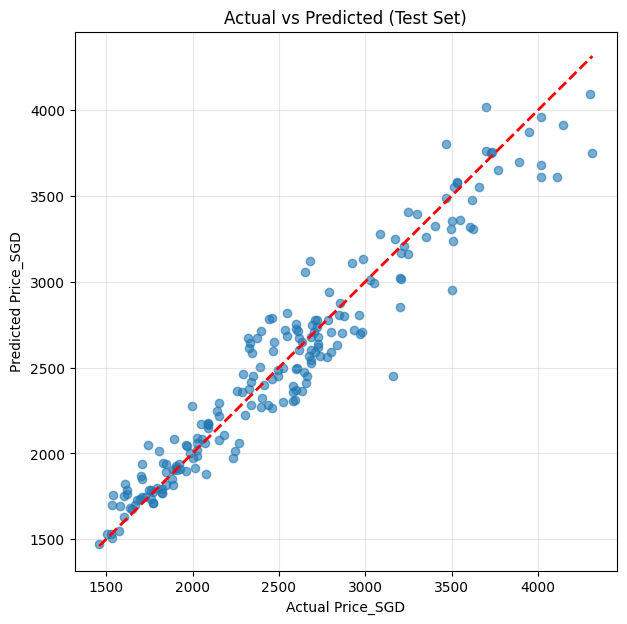


Top 10 worst predictions (by absolute percentage error):
     Actual_Price_SGD  Predicted_Price_SGD  Abs_Error_SGD  Abs_Percent_Error
179            3161.6          2447.921367     713.678633          22.573337
60             1743.6          2049.119000     305.519000          17.522310
174            2679.6          3118.756900     439.156900          16.388898
53             3503.6          2950.464133     553.135867          15.787643
145            2649.2          3054.907800     405.707800          15.314352
175            2319.6          2669.783700     350.183700          15.096728
184            1538.8          1755.733367     216.933367          14.097567
56             1997.6          2274.215800     276.615800          13.847407
71             2445.2          2780.235900     335.035900          13.701779
192            2458.8          2790.730933     331.930933          13.499713

Top 10 worst predictions with features (head):
     Unnamed: 0      Brand               Model 

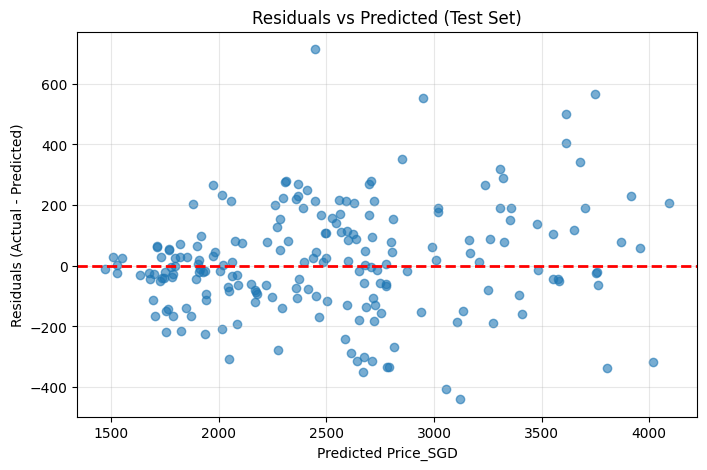


Top 10 Feature Importances:
                               feature  importance
7                 num__Member_Discount    0.820220
1                          num__RAM_GB    0.047534
31            cat__GPU_NVIDIA RTX 4070    0.028386
32            cat__GPU_NVIDIA RTX 4080    0.024452
30            cat__GPU_NVIDIA RTX 4060    0.009376
2                      num__Storage_GB    0.009230
5                num__Discount_percent    0.007475
3                       num__Weight_kg    0.006454
0                      num__Unnamed: 0    0.005318
18  cat__CPU_Intel Core Ultra 9 15700H    0.004123


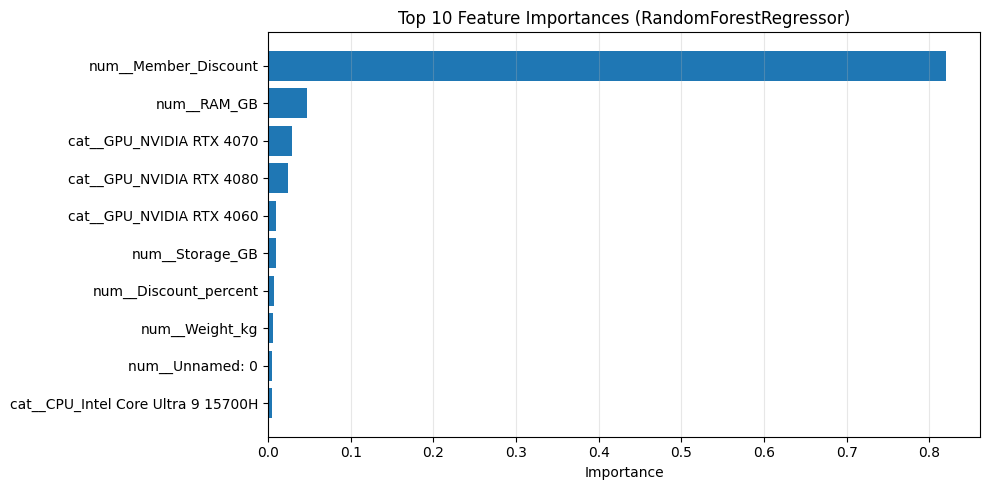

In [33]:
# CODES to start modelling from Train/Test Split till Model Evaluation for 1 model only #

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, ShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Model (tree-based regressor)
from sklearn.ensemble import RandomForestRegressor


import matplotlib.pyplot as plt


# -----------------------------
# 1) Split X and y
# -----------------------------
X = df.drop(columns=["Price_SGD"])
y = df["Price_SGD"]


# -----------------------------
# 2) Train/Test Split (test_size=0.2)
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# -----------------------------
# 3) Identify numerical and categorical columns
# -----------------------------
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.columns.difference(numeric_cols).tolist()


# -----------------------------
# 4) Create preprocessing pipeline
#    - StandardScaler for numerical
#    - OneHotEncoder for categorical
# -----------------------------
# scikit-learn versions may differ in OneHotEncoder parameter support.
# handle drop to avoid version-specific issues by using only supported basics.
ohe = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", ohe, categorical_cols),
    ],
    remainder="drop"
)


# -----------------------------
# 5) Create and train a baseline model
# -----------------------------
# Baseline model: RandomForestRegressor (tree-based regression)
model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

# Full pipeline
pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", model)
])

pipe.fit(X_train, y_train)


# -----------------------------
# Helper: RMSE (without squared=False)
# -----------------------------
def rmse_from_mse(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)  # squared=True by default
    return np.sqrt(mse)


# -----------------------------
# 6) Evaluate and tabulate baseline model (train & test)
#    metrics: MAE, RMSE, R2
#    Save to results_df
# -----------------------------
# Predictions
y_train_pred = pipe.predict(X_train)
y_test_pred = pipe.predict(X_test)

# Compute metrics
train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = rmse_from_mse(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = rmse_from_mse(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

results_df = pd.DataFrame({
    "split": ["train", "test"],
    "mae": [train_mae, test_mae],
    "rmse": [train_rmse, test_rmse],
    "r2": [train_r2, test_r2]
})

print("Baseline Results:")
print(results_df)


# -----------------------------
# 7) Predict on X_test and interpret
# -----------------------------
# Already computed y_test_pred above; show a small sample interpretation.
pred_df = X_test.copy()
pred_df["Actual_Price_SGD"] = y_test.values
pred_df["Predicted_Price_SGD"] = y_test_pred

# Interpretation: show first few rows and summary error magnitude
pred_df["Abs_Error_SGD"] = np.abs(pred_df["Actual_Price_SGD"] - pred_df["Predicted_Price_SGD"])
pred_df["APE_%"] = 100.0 * pred_df["Abs_Error_SGD"] / np.maximum(np.abs(pred_df["Actual_Price_SGD"]), 1e-9)

print("\nTest prediction sample (first 5 rows):")
print(pred_df[["Actual_Price_SGD", "Predicted_Price_SGD", "Abs_Error_SGD", "APE_%"]].head())

print("\nInterpretation (high level):")
print(f"- Test MAE = {test_mae:.3f} SGD")
print(f"- Test RMSE = {test_rmse:.3f} SGD")
print(f"- Test R2 = {test_r2:.4f} (closer to 1 is better; negative means worse than predicting the mean)")


# -----------------------------
# 8) Cross Validation with ShuffleSplit (5 splits, test_size=0.2)
# -----------------------------
cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

cv_mae_list, cv_rmse_list, cv_r2_list = [], [], []

# -----------------------------
# 9) Evaluate model using CV metrics
#    Save to cv_results_df
# -----------------------------
for fold, (train_idx, val_idx) in enumerate(cv.split(X), start=1):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # Clone pipeline by refitting a new instance (simple and version-safe)
    # (Avoid sklearn.clone issues across versions by rebuilding)
    pipe_cv = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=300, random_state=42, n_jobs=-1
        ))
    ])

    pipe_cv.fit(X_tr, y_tr)

    y_val_pred = pipe_cv.predict(X_val)

    cv_mae_list.append(mean_absolute_error(y_val, y_val_pred))
    cv_rmse_list.append(rmse_from_mse(y_val, y_val_pred))
    cv_r2_list.append(r2_score(y_val, y_val_pred))

cv_results_df = pd.DataFrame({
    "fold": np.arange(1, len(cv_mae_list) + 1),
    "cv_mae": cv_mae_list,
    "cv_rmse": cv_rmse_list,
    "cv_r2": cv_r2_list
})

# Add average row
cv_results_summary = pd.DataFrame([{
    "fold": "mean",
    "cv_mae": np.mean(cv_mae_list),
    "cv_rmse": np.mean(cv_rmse_list),
    "cv_r2": np.mean(cv_r2_list)
}])

cv_results_df = pd.concat([cv_results_df, cv_results_summary], ignore_index=True)

print("\nCross-Validation Results:")
print(cv_results_df)


# -----------------------------
# 10) Plot "Actual vs Predicted" scatter plot
# -----------------------------
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_test_pred, alpha=0.6)
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=2)
plt.xlabel("Actual Price_SGD")
plt.ylabel("Predicted Price_SGD")
plt.title("Actual vs Predicted (Test Set)")
plt.grid(True, alpha=0.3)
plt.show()


# -----------------------------
# 11) Error analysis table and save to error_df
#     Identify top 10 worst prediction errors by absolute percentage error
# -----------------------------
error_df = pd.DataFrame({
    "Actual_Price_SGD": y_test.values,
    "Predicted_Price_SGD": y_test_pred,
})

error_df["Abs_Error_SGD"] = np.abs(error_df["Actual_Price_SGD"] - error_df["Predicted_Price_SGD"])
error_df["Abs_Percent_Error"] = 100.0 * error_df["Abs_Error_SGD"] / np.maximum(np.abs(error_df["Actual_Price_SGD"]), 1e-9)

# Top 10 worst by APE%
error_df_sorted = error_df.sort_values("Abs_Percent_Error", ascending=False)
top10_worst = error_df_sorted.head(10).copy()

print("\nTop 10 worst predictions (by absolute percentage error):")
print(top10_worst)

# Optional: attach corresponding features too for interpretability
error_with_features_df = X_test.copy()
error_with_features_df = error_with_features_df.reset_index(drop=True)
error_with_features_df = error_with_features_df.join(error_df.reset_index(drop=True))

top10_worst_with_features = error_with_features_df.loc[top10_worst.index]
print("\nTop 10 worst predictions with features (head):")
print(top10_worst_with_features.head(10))


# -----------------------------
# 12) Create a Residuals vs Predicted Plot
# -----------------------------
residuals = y_test.values - y_test_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_test_pred, residuals, alpha=0.6)
plt.axhline(0, color="red", linestyle="--", linewidth=2)
plt.xlabel("Predicted Price_SGD")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residuals vs Predicted (Test Set)")
plt.grid(True, alpha=0.3)
plt.show()


# -----------------------------
# 13) Create a Top 10 Feature Importance Plot
# -----------------------------
# For RandomForest, feature_importances_ exists.
# We need to map importance values to feature names after preprocessing.
# This can vary in scikit-learn versions; handle robustly.

# Get trained RF model
rf_model = pipe.named_steps["model"]

# Get feature names from preprocessor
# scikit-learn >= 1.0 has get_feature_names_out for transformers/pipelines
feature_names = None
try:
    feature_names = pipe.named_steps["preprocess"].get_feature_names_out()
except Exception:
    # Fallback: approximate names if get_feature_names_out unavailable
    # Numerical columns keep their names; categorical expanded names are unknown
    feature_names = []
    for col in numeric_cols:
        feature_names.append(col)
    # For categorical, create generic names
    # OneHotEncoder categories length can be used
    try:
        cat_encoder = pipe.named_steps["preprocess"].named_transformers_["cat"]
        for i, col in enumerate(categorical_cols):
            cats = cat_encoder.categories_[i]
            for c in cats:
                feature_names.append(f"{col}__{c}")
    except Exception:
        # Last resort: numeric-only
        feature_names = [f"feature_{i}" for i in range(len(rf_model.feature_importances_))]

importances = rf_model.feature_importances_
# Ensure alignment length
if len(feature_names) != len(importances):
    feature_names = [f"feature_{i}" for i in range(len(importances))]

fi_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

top10_fi = fi_df.head(10)

print("\nTop 10 Feature Importances:")
print(top10_fi)

plt.figure(figsize=(10, 5))
plt.barh(top10_fi["feature"][::-1], top10_fi["importance"][::-1])
plt.xlabel("Importance")
plt.title("Top 10 Feature Importances (RandomForestRegressor)")
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()



#<font color = 'red'>**Ask LLM to start modelling from Train/Test Split till Model Evaluation for 2 models only. Compare which model is better**

In [36]:
df = cleaned_df
from sklearn import sklearn
sklearn_ver=sklearn.__version__
np_version = np.__version__
pd_version = pd.__version__
#mse = mean_squared_error(y_true, y_pred)
#rmse = np.sqrt(mse)

prompt_models = f"""
You are an expert data scientist with experience in tree-based regression models.
Dataset is df. Target is column 'Price_SGD'.
X and y for modelling where X is the input features without target and y is the target
Based on these versions {sklearn_ver} , {pd_version} and {np_version}, generate code that is compatible with different versions of scikit-learn.
Do not use mean_squared_error(..., squared=False). Compute RMSE by first calculating MSE and then taking the square root using NumPy
Generate simple, executable Python codes with comments:
1. Split X and y
2. Train/Test Split using test_size=0.2
3. Identify numerical and categorical columns
4. Create preprocessing pipeline using ColumnTransformer ( StandardScaler for numerical columns, onehotencoder for categorical columns)
5. Create and train 2 models, Random Forest and XGBoost
6. Evaluate, tabulate and compare both models (mae,rsme,r2) for train and test. Save the results to results_df.
7. Use the pipeline and the models to predict on X_test, and interpret the results
8. Perform Cross Validation using ShuffleSplit (5 splits) with the same test size (20%)
9. Evaluate, tabulate and compare the models using cv_mae, cv_rmse, cv_r2. Save the results to cv_results_df
10. Based on the model with the best CV validation MAE, plot "Actual vs Predicted" scatter plot
11. Create error analysis table ( with absolute error and absolute percentage error) for the best model with test set. Save the results ro error_df. Sort by absolute error to show top 10 largest errors
12. Create a Residuals vs Predicted Plot for the best model
13. Create a Top 10 Feature Importance Plot for the best model
"""

print('=== Prompt to send ===')
print(prompt_models)

if client is not None:
    response_models = client.responses.create(
        model=OPENAI_MODEL,
        input=prompt_models
    )
    print('\n=== LLM response ===')
    print(response_models.output_text)
else:
    print('\nNo API response because client is not connected. Copy the prompt above into your chatbot.')

=== Prompt to send ===

You are an expert data scientist with experience in tree-based regression models.
Dataset is df. Target is column 'Price_SGD'.
X and y for modelling where X is the input features without target and y is the target
Based on these versions 1.6.1 , 2.2.2 and 2.0.2, generate code that is compatible with different versions of scikit-learn.
Do not use mean_squared_error(..., squared=False). Compute RMSE by first calculating MSE and then taking the square root using NumPy
Generate simple, executable Python codes with comments:
1. Split X and y
2. Train/Test Split using test_size=0.2
3. Identify numerical and categorical columns
4. Create preprocessing pipeline using ColumnTransformer ( StandardScaler for numerical columns, onehotencoder for categorical columns)
5. Create and train 2 models, Random Forest and XGBoost
6. Evaluate, tabulate and compare both models (mae,rsme,r2) for train and test. Save the results to results_df.
7. Use the pipeline and the models to predi

=== Test/Train comparison (results_df) ===
              train_mae  train_rmse  train_r2   test_mae   test_rmse   test_r2
model                                                                         
RandomForest  35.317763    46.57064  0.996525  81.369848  106.055918  0.979514
XGBoost        7.394618     9.48036  0.999856  58.026687   75.137379  0.989717

=== Best model by TEST MAE ===
Best model: XGBoost
Test MAE: 58.026687426757796
Test RMSE: 75.13737863399946
Test R2: 0.98971731220975

Sample predictions (first 10 rows of X_test):
      Actual    Predicted
521  3056.76  3123.281494
737  2005.05  2017.069824
740  3299.06  3228.454102
660  2256.04  2242.893311
411  2722.71  2851.067627
678  3012.86  3033.636230
626  3135.26  3222.759521
513  2549.66  2692.757324
859  2303.14  2270.454346
136  2780.58  2888.312256

=== Cross-validation comparison (cv_results_df) ===
              cv_mae_mean  cv_mae_std  cv_rmse_mean  cv_rmse_std  cv_r2_mean  \
model                                  

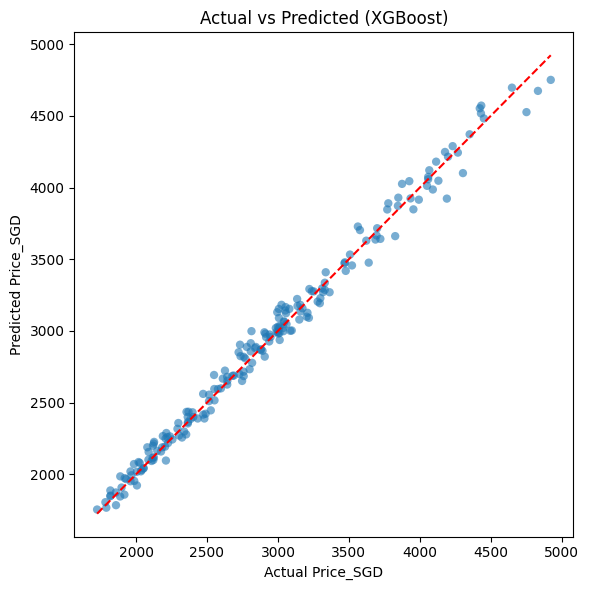


=== Top 10 largest errors (error_df) ===
      Actual    Predicted  AbsoluteError  AbsolutePercentageError
51   4190.58  3922.948975     267.631025                 6.386491
100  4751.72  4526.226074     225.493926                 4.745522
98   4303.91  4100.907227     203.002773                 4.716706
177  2813.52  2998.396240     184.876240                 6.570994
144  4922.89  4751.040039     171.849961                 3.490835
11   2732.72  2903.895752     171.175752                 6.263933
197  3826.40  3661.278809     165.121191                 4.315314
179  3563.30  3728.219238     164.919238                 4.628273
162  3639.80  3476.229736     163.570264                 4.493935
143  4832.62  4674.304199     158.315801                 3.275983


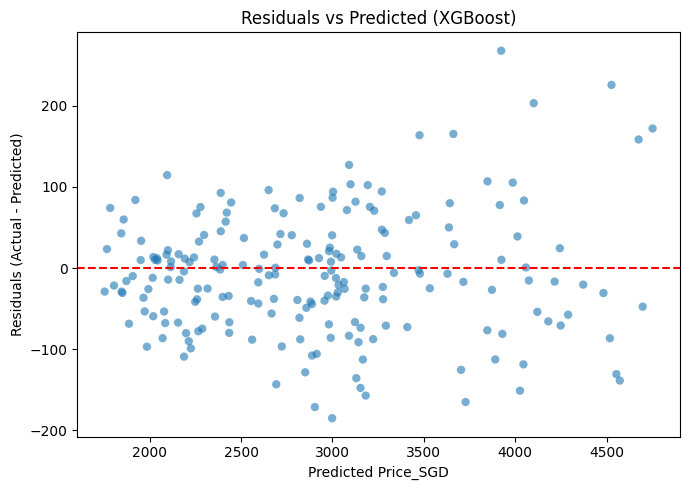

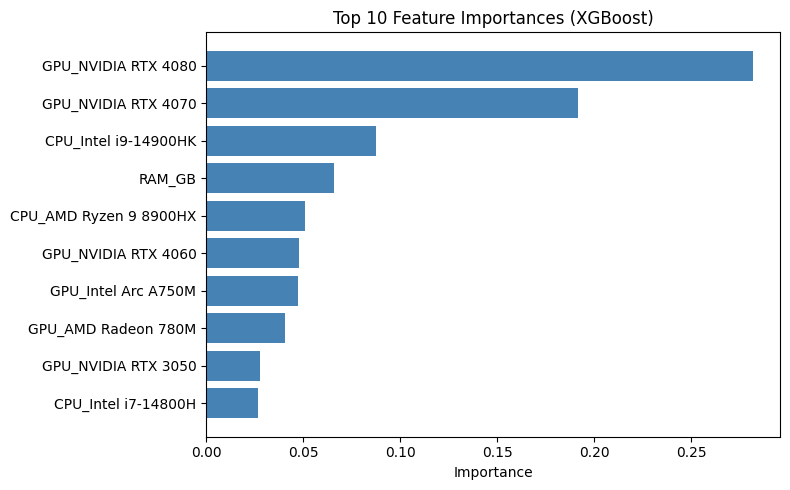

In [37]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, ShuffleSplit, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.metrics import mean_absolute_error, r2_score

from sklearn.ensemble import RandomForestRegressor

# ----------------------------
# 1) Split X and y
# ----------------------------
target_col = "Price_SGD"
X = df.drop(columns=[target_col])
y = df[target_col]

# ----------------------------
# 2) Train/Test Split using test_size=0.2
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ----------------------------
# 3) Identify numerical and categorical columns
# ----------------------------
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X_train.columns if c not in numeric_cols]

# ----------------------------
# 4) Create preprocessing pipeline
#    - StandardScaler for numerical columns
#    - OneHotEncoder for categorical columns
# ----------------------------
# Handle OneHotEncoder parameter differences across sklearn versions:
# - Some versions use sparse_output=..., older use sparse=...
ohe_params = {"handle_unknown": "ignore"}
try:
    # sklearn >= 1.2: sparse_output exists
    ohe_params["sparse_output"] = False
except TypeError:
    # older sklearn: sparse exists
    ohe_params["sparse"] = False

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(**ohe_params), categorical_cols),
    ],
    remainder="drop"
)

# ----------------------------
# 5) Train/Test: 2 models
#    - Random Forest
#    - XGBoost
# ----------------------------
# XGBoost compatibility: use xgboost if installed.
# If not installed, install: pip install xgboost
try:
    from xgboost import XGBRegressor
    xgb_available = True
except ImportError:
    xgb_available = False
    XGBRegressor = None

# Random Forest model (good baseline)
rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

# XGBoost model (common defaults + safe parameters)
if xgb_available:
    xgb_model = XGBRegressor(
        n_estimators=800,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.0,
        reg_lambda=1.0,
        random_state=42,
        objective="reg:squarederror"
    )
else:
    xgb_model = None

# Create pipelines: preprocessing + model
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", rf_model)
])

if xgb_model is not None:
    xgb_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", xgb_model)
    ])

# ----------------------------
# Helper to compute RMSE without squared=False
# ----------------------------
def rmse_from_mse(mse):
    return float(np.sqrt(mse))

def evaluate_model(pipeline, X_train, y_train, X_test, y_test):
    # Train
    pipeline.fit(X_train, y_train)

    # Predict train/test
    y_pred_train = pipeline.predict(X_train)
    y_pred_test = pipeline.predict(X_test)

    # Metrics
    mae_train = mean_absolute_error(y_train, y_pred_train)
    mae_test = mean_absolute_error(y_test, y_pred_test)

    # MSE then sqrt -> RMSE (as requested)
    mse_train = np.mean((y_train - y_pred_train) ** 2)
    mse_test = np.mean((y_test - y_pred_test) ** 2)
    rmse_train = rmse_from_mse(mse_train)
    rmse_test = rmse_from_mse(mse_test)

    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)

    return {
        "train_mae": mae_train,
        "train_rmse": rmse_train,
        "train_r2": r2_train,
        "test_mae": mae_test,
        "test_rmse": rmse_test,
        "test_r2": r2_test,
    }

# ----------------------------
# 6) Evaluate, tabulate and compare both models
#    Save results to results_df
# ----------------------------
results = []

# Random Forest evaluation
rf_metrics = evaluate_model(rf_pipeline, X_train, y_train, X_test, y_test)
results.append({
    "model": "RandomForest",
    **rf_metrics
})

# XGBoost evaluation (if available)
if xgb_pipeline is not None:
    xgb_metrics = evaluate_model(xgb_pipeline, X_train, y_train, X_test, y_test)
    results.append({
        "model": "XGBoost",
        **xgb_metrics
    })

results_df = pd.DataFrame(results).set_index("model")
print("=== Test/Train comparison (results_df) ===")
print(results_df)

# ----------------------------
# 7) Predict on X_test using the pipeline and interpret results
# ----------------------------
# Choose best test MAE for quick test interpretation (not CV-based)
best_model_name = results_df["test_mae"].idxmin()
best_pipeline = rf_pipeline if best_model_name == "RandomForest" else xgb_pipeline

# Fit already happened inside evaluate_model, but we refit best to be safe
best_pipeline.fit(X_train, y_train)
y_pred_test_best = best_pipeline.predict(X_test)

# Basic interpretation: show a compact summary + few samples
print("\n=== Best model by TEST MAE ===")
print(f"Best model: {best_model_name}")
print("Test MAE:", results_df.loc[best_model_name, "test_mae"])
print("Test RMSE:", results_df.loc[best_model_name, "test_rmse"])
print("Test R2:", results_df.loc[best_model_name, "test_r2"])

print("\nSample predictions (first 10 rows of X_test):")
sample_df = X_test.head(10).copy()
sample_df["Actual"] = y_test.head(10).values
sample_df["Predicted"] = y_pred_test_best[:10]
print(sample_df[["Actual", "Predicted"]])

# ----------------------------
# 8) Perform Cross Validation using ShuffleSplit (5 splits)
#    same test size = 0.2
# ----------------------------
cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

# ----------------------------
# 9) Evaluate using cv_mae, cv_rmse, cv_r2
#    Save to cv_results_df
# ----------------------------
def cv_rmse_scorer(estimator, Xv, yv):
    # cross_validate will pass yv as true labels
    y_pred = estimator.predict(Xv)
    mse = np.mean((yv - y_pred) ** 2)
    return rmse_from_mse(mse)

# We'll use scoring dict with callables for RMSE and MAE, plus r2 string.
# String scorers are stable across sklearn versions; callable scorers also work.
scoring = {
    "cv_mae": "neg_mean_absolute_error",  # sklearn returns negative -> convert later
    "cv_rmse": cv_rmse_scorer,
    "cv_r2": "r2"
}

def cross_validate_model(pipeline, X, y, cv):
    cv_out = cross_validate(
        pipeline, X, y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    # cv_out contains arrays for each scorer
    # Convert neg MAE to positive MAE:
    cv_mae_scores = -cv_out["test_cv_mae"]
    cv_rmse_scores = cv_out["test_cv_rmse"]
    cv_r2_scores = cv_out["test_cv_r2"]

    return {
        "cv_mae_mean": float(np.mean(cv_mae_scores)),
        "cv_mae_std": float(np.std(cv_mae_scores)),
        "cv_rmse_mean": float(np.mean(cv_rmse_scores)),
        "cv_rmse_std": float(np.std(cv_rmse_scores)),
        "cv_r2_mean": float(np.mean(cv_r2_scores)),
        "cv_r2_std": float(np.std(cv_r2_scores)),
    }

cv_results = []

cv_rf = cross_validate_model(rf_pipeline, X, y, cv)
cv_results.append({"model": "RandomForest", **cv_rf})

if xgb_pipeline is not None:
    cv_xgb = cross_validate_model(xgb_pipeline, X, y, cv)
    cv_results.append({"model": "XGBoost", **cv_xgb})

cv_results_df = pd.DataFrame(cv_results).set_index("model")
print("\n=== Cross-validation comparison (cv_results_df) ===")
print(cv_results_df)

# ----------------------------
# Select best model by CV validation MAE
# ----------------------------
best_cv_model_name = cv_results_df["cv_mae_mean"].idxmin()
best_cv_pipeline = rf_pipeline if best_cv_model_name == "RandomForest" else xgb_pipeline
print("\nBest model by CV MAE:", best_cv_model_name)

# ----------------------------
# 10) Plot "Actual vs Predicted" scatter for best CV model (test split)
# ----------------------------
# Fit best CV model on train split
best_cv_pipeline.fit(X_train, y_train)
y_pred_test_cvbest = best_cv_pipeline.predict(X_test)

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_test_cvbest, alpha=0.6, edgecolors="none")
min_val = min(np.min(y_test), np.min(y_pred_test_cvbest))
max_val = max(np.max(y_test), np.max(y_pred_test_cvbest))
plt.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=1.5)
plt.xlabel("Actual Price_SGD")
plt.ylabel("Predicted Price_SGD")
plt.title(f"Actual vs Predicted ({best_cv_model_name})")
plt.tight_layout()
plt.show()

# ----------------------------
# 11) Error analysis table for best model (test set)
#     - absolute error
#     - absolute percentage error
#     Sort by absolute error top 10 largest errors
#     Save to error_df
# ----------------------------
abs_error = np.abs(y_test.values - y_pred_test_cvbest)
# Avoid division by zero: if actual is 0, set percentage error to NaN or inf-like.
with np.errstate(divide="ignore", invalid="ignore"):
    abs_pct_error = np.where(
        y_test.values != 0,
        (abs_error / np.abs(y_test.values)) * 100.0,
        np.nan
    )

error_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_test_cvbest,
    "AbsoluteError": abs_error,
    "AbsolutePercentageError": abs_pct_error
})

error_df = error_df.sort_values(by="AbsoluteError", ascending=False)
top10_largest_errors = error_df.head(10)

print("\n=== Top 10 largest errors (error_df) ===")
print(top10_largest_errors)

# ----------------------------
# 12) Residuals vs Predicted plot for the best model
# ----------------------------
residuals = y_test.values - y_pred_test_cvbest

plt.figure(figsize=(7, 5))
plt.scatter(y_pred_test_cvbest, residuals, alpha=0.6, edgecolors="none")
plt.axhline(0, color="red", linestyle="--", linewidth=1.5)
plt.xlabel("Predicted Price_SGD")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title(f"Residuals vs Predicted ({best_cv_model_name})")
plt.tight_layout()
plt.show()

# ----------------------------
# 13) Top 10 Feature Importance Plot for the best model
#     - Works best for RandomForest (feature_importances_)
#     - For XGBoost, also uses feature_importances_ if available
# ----------------------------
# Extract feature names after preprocessing
# Get names from preprocessor; OneHotEncoder may expand features.
pre = best_cv_pipeline.named_steps["preprocessor"]
ohe = None
if "cat" in [name for name, _, _ in pre.transformers]:
    # find the OneHotEncoder in the transformer
    for name, transformer, cols in pre.transformers_:
        if name == "cat":
            ohe = transformer

# Build feature name list:
num_feature_names = numeric_cols
cat_feature_names = []
if categorical_cols and ohe is not None:
    # feature_names_out is stable for newer sklearn; fallback for older
    try:
        # sklearn >= 1.0+
        cat_feature_names = ohe.get_feature_names_out(categorical_cols).tolist()
    except Exception:
        cat_feature_names = []
        # fallback: approximate names
        for col in categorical_cols:
            cat_feature_names.append(f"{col}_onehot")

all_feature_names = num_feature_names + cat_feature_names

# Extract model feature importances (if available)
model = best_cv_pipeline.named_steps["model"]
importances = None

if hasattr(model, "feature_importances_"):
    importances = model.feature_importances_

if importances is None:
    print("\nFeature importance not available for this model.")
else:
    # Safety: align lengths
    importances = np.asarray(importances)
    if len(importances) != len(all_feature_names):
        # If mismatch, create generic names
        if len(importances) > len(all_feature_names):
            all_feature_names = all_feature_names + [f"feature_{i}" for i in range(len(all_feature_names), len(importances))]
        else:
            all_feature_names = all_feature_names[:len(importances)]

    fi_df = pd.DataFrame({
        "feature": all_feature_names,
        "importance": importances
    }).sort_values(by="importance", ascending=False)

    top10_fi = fi_df.head(10)

    plt.figure(figsize=(8, 5))
    plt.barh(top10_fi["feature"][::-1], top10_fi["importance"][::-1], color="steelblue")
    plt.xlabel("Importance")
    plt.title(f"Top 10 Feature Importances ({best_cv_model_name})")
    plt.tight_layout()
    plt.show()

#**<font color='red'> ** Based on the model and CV metrics to check with Model is the best**

In [38]:
# WHICH MODEL IS THE BEST #

prompt_choose = f"""
You are an expert data scientist with experience in tree-based regression models.

You are given the following information:
- {results_df}
- {cv_results_df}

1. Which model has lower CV validation MAE?
2. Is the train MAE much lower than the validation MAE?
3. Is the train-validation gap acceptable? What is the implication if test is much larger than validation?
4. Suggest specific hyperparameter directions (e.g., max_depth, min_child_weight, subsample, colsample_bytree, reg_alpha/reg_lambda, learning_rate) to reduce the train–validation gap for the better model
5. Does the holdout MAE support the CV result?
6. Are there overfitting issues?
7. Overall, which model is the best and explain why? Give the ansewer using below format:
The selected model is ______.
Compared with the mean-price baseline, it ______.
The test MAE means that ______.
The visual checks show that ______.
The error band / brand analysis shows that ______.
The feature importance check suggests that the model relies on ______.
However, I should be careful because ______.
Therefore, I would / would not recommend using this model for ______.
A sensible next step is ______.
"""
print('=== Prompt to send ===')
print(prompt_choose)

if client is not None:
    response_choose = client.responses.create(
        model=OPENAI_MODEL,
        input=prompt_choose
    )
    print('\n=== LLM response ===')
    print(response_choose.output_text)
else:
    print('\nNo API response because client is not connected. Copy the prompt above into your chatbot.')

=== Prompt to send ===

You are an expert data scientist with experience in tree-based regression models.

You are given the following information:
-               train_mae  train_rmse  train_r2   test_mae   test_rmse   test_r2
model                                                                         
RandomForest  35.317763    46.57064  0.996525  81.369848  106.055918  0.979514
XGBoost        7.394618     9.48036  0.999856  58.026687   75.137379  0.989717
-               cv_mae_mean  cv_mae_std  cv_rmse_mean  cv_rmse_std  cv_r2_mean  \
model                                                                          
RandomForest    91.323834    6.384240    122.246765    10.046113    0.973805   
XGBoost         63.324408    2.946748     82.665387     5.071054    0.988096   

              cv_r2_std  
model                    
RandomForest   0.004271  
XGBoost        0.001021  

1. Which model has lower CV validation MAE?
2. Is the train MAE much lower than the validation MAE?
3. Is 